# Imaging a modulation

A spin density wave, a screened impurity, a domain wall: each of them is a slow
envelope on a crystal that is still atomically periodic, and the way one is
actually seen is with a scanning-tunnelling microscope. The previous notebook
computes such a wave in the unit cell's own states; this one looks at it the way
an experiment would.

In the Tersoff-Hamann picture the current an s-wave tip draws is the sample's
local density of states at the tip, at the energy the bias selects, so the image
is the same density read with a smeared delta at the tip energy in place of the
occupations. The states that made the wave are the ones that make the image.

**What a tip measures is not the charge density**, and a magnetic wave is where
the difference shows. A tip polarized along the wave's axis sees the wave itself,
one period over the eight cells, and reversing the tip gives the image shifted by
half a period, which is the other spin channel. An unpolarized tip does not see
nothing: it sees the wave squared, **two** periods over the eight cells, because
a collinear crystal is unchanged by flipping every spin at the same time as the
sign of the applied field, so the charge cannot respond at first order and its
leading response is at twice the wavevector. On a cell carrying 0.12 Bohr
magnetons the two come out at **82 per cent** and **37 per cent** of their means
from cell to cell, where the total charge density itself is modulated by 1.9
parts in ten thousand, at those same two periods: the density of states at one
energy is a far more sensitive quantity than the density, and the factor of two
thousand between them is what makes the wave something a tip can see at all.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from defumat import Calculator

magnetic = Calculator.from_file('../tests/data/qe/si-ultracell-mag.in',
                                pseudo_dir='../tests/data/pseudo')
field = lambda x: 0.02 * np.cos(2 * np.pi * x[..., 0] / 8)
wave = magnetic.get_ultracell(supercell=(8, 1, 1), kgrid=(1, 2, 2), nbnd=32,
                              magnetic_field=field, david=2, states_conv_thr=1e-5)
print(f'largest cell moment {np.abs(wave.cell_moments()).max():.4f} mu_B')

[defumat] an ultracell calculation: no ground state cached, running the SCF first (conv_thr = 1e-10). Call get_scf() to do this explicitly.


/u/40/ladovj1/data/Documents/programs/claude/defumat/defumat/ultracell/driver.py:635: UserWarning: the fixed-density solve did not converge at 14 of 64 k-points: up to 2 of 32 bands are unsettled and the worst k-point took 100 Davidson steps, at ethr = 1.3e-07 (from conv_thr = 1.0e-05). There is no later iteration to fix this -- the density is fixed -- so these wavefunctions are what every quantity built on them will use. Loosen conv_thr (ethr is 0.1 x conv_thr / nelec, QE's setup.f90 rule) before raising the iteration budget: a threshold the solve cannot reach costs the whole budget at every k-point and is where an overlap loses positivity
  calculation, folded_system, eigenvalues, wavefunctions = fixed_density_states(


largest cell moment 0.1223 mu_B


## What the tip is tuned to

Silicon has a gap, and this run is a smeared one, so the Fermi level it reports
sits inside that gap: 0.47 smearing widths above the top of the valence band and
0.67 below the bottom of the conduction band. The zero-bias image is then the
tail of those two edges at the tip energy, which is the most sensitive thing a
tip can be tuned to, since a level that moves by a fraction of a width changes
the weight there by a large factor while the same shift moves the occupied
density hardly at all. That is the whole of why the numbers below are percentages
where the density's own modulation is parts in ten thousand. On a metal the same
call with no bias gives the Fermi surface instead, and where a gap is wide enough
that its tails carry nothing, a negative bias images the filled states below it.

`spin` is the tip's own moment. With `polarization = 1` the image is a single
spin channel; with the default of `None` it is the charge, which is what an
ordinary tip measures.

In [2]:
plane = dict(height=0.35, axis=2, shape=(96, 12))
images = {'charge': magnetic.get_ultracell_stm(**plane),
          'one spin channel': magnetic.get_ultracell_stm(spin='up', **plane)}

# the tip's current averaged over each of the eight cells, in units of its mean
def envelope(image):
    per_cell = np.asarray(image.values).mean(axis=1).reshape(8, -1).mean(axis=1)
    return per_cell / per_cell.mean()

for label, image in images.items():
    print(f'{label:17s} varies by {np.ptp(envelope(image)) * 100:6.3f} % '
          f'from cell to cell')


charge            varies by 37.084 % from cell to cell
one spin channel  varies by 81.630 % from cell to cell


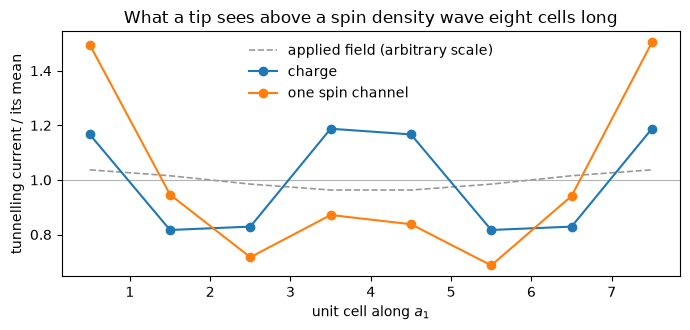

In [3]:
cells = np.arange(8) + 0.5
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.axhline(1.0, color='0.7', lw=0.8)
ax.plot(cells, 1 + 0.04 * np.cos(2 * np.pi * cells / 8), color='0.6', lw=1.2,
        ls='--', label='applied field (arbitrary scale)')
for label, image in images.items():
    ax.plot(cells, envelope(image), 'o-', label=label)
ax.set_xlabel('unit cell along $a_1$')
ax.set_ylabel('tunnelling current / its mean')
ax.set_title('What a tip sees above a spin density wave eight cells long')
ax.legend(frameon=False)
fig.tight_layout()


## Reading it

One spin channel follows the applied field cell by cell, and the other is the
same curve moved four cells along, which is half a period: the two channels are
mirror images and their sum is what an unpolarized tip sees. That sum is not
flat, and its maxima sit where the moment is largest in **magnitude** rather than
where it is largest, which is what "the charge follows the square of the wave"
means when it is read off a picture.

The wave has one period over the eight cells because the applied field does, and
its amplitude is the spin susceptibility at that wavelength: the quantity a
long-period magnet is characterised by, and the one a supercell is too expensive
to reach.

An image like this is a plane through the crystal rather than a surface above it,
because the cell here is bulk silicon. Above a real surface the same quantity is
the image itself, and the tip height is then the distance into the vacuum: the
tunnelling density falls by orders of magnitude across it, which is what makes an
STM sensitive to the outermost layer alone.


## At every bias, not only at oneAn image answers how much weight there is at the tip and says nothing about wherein energy it sits. A modulation moves the two spin channels apart from cell tocell, so what a tip finds if the bias is swept at one place is a curve whosefeatures move as the tip is walked along the wave, and that is the measurementan experiment calls a spectrum. `get_ultracell_sts()` takes it, at a point, alonga line, or over a whole plane at every energy.The states do not depend on the bias, so they are sampled at the tip once andevery energy after that is a matrix product: forty-one biases here cost four percent more than one, where forty-one images cost forty-one times an image.

In [4]:
tips = np.stack([np.arange(8) + 0.5, np.full(8, 0.5), np.full(8, 0.35)], axis=-1)
# a window on the conduction edge, which is where the weight is at
# this tip height; the filled states below the gap are three smearing
# widths away and contribute almost nothing here
bias = wave.fermi_energy + np.linspace(-0.06, 0.06, 41)
channels = {name: magnetic.get_ultracell_sts(energies=bias, tip=tips,
                                             width=0.02, spin=name)
            for name in ('up', 'down')}

# where each channel's curve peaks, cell by cell, in eV from the Fermi level
edges = {name: sts.bias_axis[np.argmax(np.asarray(sts.values), axis=0)] * 13.6057
         for name, sts in channels.items()}
for name, edge in edges.items():
    print(f'{name:5s} peak moves {np.ptp(edge):.2f} eV, highest at cell '
          f'{np.argmax(edge)}, lowest at cell {np.argmin(edge)}')
print(f'the two channels are {abs(np.argmax(edges["up"]) - np.argmax(edges["down"]))}'
      f' cells apart, on a wave eight cells long')

up    peak moves 0.33 eV, highest at cell 3, lowest at cell 7
down  peak moves 0.33 eV, highest at cell 7, lowest at cell 3
the two channels are 4 cells apart, on a wave eight cells long


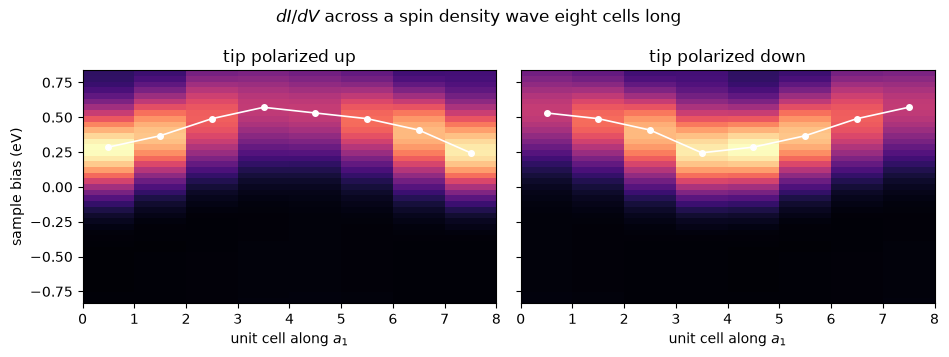

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharey=True)
top = max(np.asarray(sts.values).max() for sts in channels.values())
for ax, (name, sts) in zip(axes, channels.items()):
    values = np.asarray(sts.values)
    ax.pcolormesh(np.arange(8) + 0.5, sts.bias_axis * 13.6057, values,
                  shading='nearest', cmap='magma', vmin=0.0, vmax=top)
    ax.plot(np.arange(8) + 0.5, edges[name], 'o-', color='white', lw=1.2, ms=4)
    ax.set_xlabel('unit cell along $a_1$')
    ax.set_title(f'tip polarized {name}')
axes[0].set_ylabel('sample bias (eV)')
fig.suptitle('$dI/dV$ across a spin density wave eight cells long')
fig.tight_layout()

The two channels peak at opposite ends of the wave, four cells apart on a waveeight cells long, which is the half period an image of them also shows. What thespectrum adds is the axis it happens on: the edge moves by about a third of anelectronvolt through the wave, where the image only records that the brightnesschanged. That splitting in energy is what an experiment fits an exchangesplitting to, and it is not something a brightness can be converted into, since alevel that moves and a level that gains weight look the same at one bias.The swing is smaller than the applied field's own, which is 0.54 eV from one endof the wave to the other. The difference is the response: the field drives amoment, the moment splits the bands, and neither step is rigid. Reading that ratioas a susceptibility is a further calculation and not something this figuremeasures.The white line follows the maximum of each curve, which is a good tracker onlywhile the window holds one feature. Widen it until the next conduction featurecomes in and the line jumps to that instead, which is a property of taking amaximum and not of the crystal.Note what the two panels share, colour scale included. They are the same crystaland the same states; only the tip's moment differs, and reversing it moves thewhole pattern half a period along. An unpolarized tip averages the two, so itsfeatures sit where the moment is largest in magnitude, at twice the period, forthe same reason its image does.

## The current that goes through

The same states answer a second question. An electron that enters at the tip and
leaves into a substrate *below* the material has gone through it rather than into
it, and what decides that current is the Green's function between the two points
instead of the density of states at one. `get_ultracell_transport()` computes it,
and it needs a material one cell deep along the stacking direction with the
modulation in the surface plane, which is where a charge density wave or a domain
wall lies in any case. Where several bands are degenerate at the tip energy they
interfere on the way through, and the map departs from the image above by exactly
that interference, which is reported beside it.

The checks live in `tests/regression/test_ultracell_stm.py`: the image of an
unmodulated long cell against the ordinary cell's own image tiled, the sum rule
against the density of states, and the modulated image against a real supercell
run in full, where the disagreement falls from 22 per cent at twelve bands to 2
per cent at forty-eight.